<a href="https://colab.research.google.com/github/marcohinojosag/IA_MKTR/blob/branch-L/cod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Importación de librerias y carga del dataset

In [155]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from kagglehub import KaggleDatasetAdapter

In [156]:
# Sets path
test_path = "aps_failure_test_set.csv"
train_path = "aps_failure_training_set.csv"

# Load the latest version
test = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "uciml/aps-failure-at-scania-trucks-data-set",
  test_path,
)

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "uciml/aps-failure-at-scania-trucks-data-set",
  train_path,
)

Using Colab cache for faster access to the 'aps-failure-at-scania-trucks-data-set' dataset.
Using Colab cache for faster access to the 'aps-failure-at-scania-trucks-data-set' dataset.


#1. Analisis del dataset train


In [157]:
# Muestra de los datos
print(df.head(5))

  class  aa_000 ab_000      ac_000 ad_000 ae_000 af_000 ag_000 ag_001 ag_002  \
0   neg   76698     na  2130706438    280      0      0      0      0      0   
1   neg   33058     na           0     na      0      0      0      0      0   
2   neg   41040     na         228    100      0      0      0      0      0   
3   neg      12      0          70     66      0     10      0      0      0   
4   neg   60874     na        1368    458      0      0      0      0      0   

   ...   ee_002  ee_003  ee_004  ee_005  ee_006  ee_007  ee_008 ee_009 ef_000  \
0  ...  1240520  493384  721044  469792  339156  157956   73224      0      0   
1  ...   421400  178064  293306  245416  133654   81140   97576   1500      0   
2  ...   277378  159812  423992  409564  320746  158022   95128    514      0   
3  ...      240      46      58      44      10       0       0      0      4   
4  ...   622012  229790  405298  347188  286954  311560  433954   1218      0   

  eg_000  
0      0  
1      0  

In [158]:
# Tamaño del dataset
print(df.shape)

(60000, 171)


In [159]:
# Se cambia la columna "class" a "clase"
df.rename(columns={'class': 'clase'}, inplace=True)

df.columns

Index(['clase', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000',
       'ag_000', 'ag_001', 'ag_002',
       ...
       'ee_002', 'ee_003', 'ee_004', 'ee_005', 'ee_006', 'ee_007', 'ee_008',
       'ee_009', 'ef_000', 'eg_000'],
      dtype='object', length=171)

In [160]:
# Reemplazo de "na" por NaN
df = df.replace("na", np.nan)

print(df.head(5))

  clase  aa_000 ab_000      ac_000 ad_000 ae_000 af_000 ag_000 ag_001 ag_002  \
0   neg   76698    NaN  2130706438    280      0      0      0      0      0   
1   neg   33058    NaN           0    NaN      0      0      0      0      0   
2   neg   41040    NaN         228    100      0      0      0      0      0   
3   neg      12      0          70     66      0     10      0      0      0   
4   neg   60874    NaN        1368    458      0      0      0      0      0   

   ...   ee_002  ee_003  ee_004  ee_005  ee_006  ee_007  ee_008 ee_009 ef_000  \
0  ...  1240520  493384  721044  469792  339156  157956   73224      0      0   
1  ...   421400  178064  293306  245416  133654   81140   97576   1500      0   
2  ...   277378  159812  423992  409564  320746  158022   95128    514      0   
3  ...      240      46      58      44      10       0       0      0      4   
4  ...   622012  229790  405298  347188  286954  311560  433954   1218      0   

  eg_000  
0      0  
1      0  

In [161]:
# Separacion de negativos y positivos
df_neg = df[df['clase'] == 'neg']
df_pos = df[df['clase'] == 'pos']

In [162]:
# Cantidad de positivos y negativos del dataset
cant_neg = len(df_neg)
cant_pos = len(df_pos)
print(f"Negativos: {cant_neg}, Positivos: {cant_pos}")

Negativos: 59000, Positivos: 1000


# 2. Obtener columnas a eliminar por vacio

In [163]:
# Porcentaje de valores vacíos por columna
cv = df.isna().sum()/len(df)
cv_neg = df_neg.isna().sum()/cant_neg
cv_pos = df_pos.isna().sum()/cant_pos

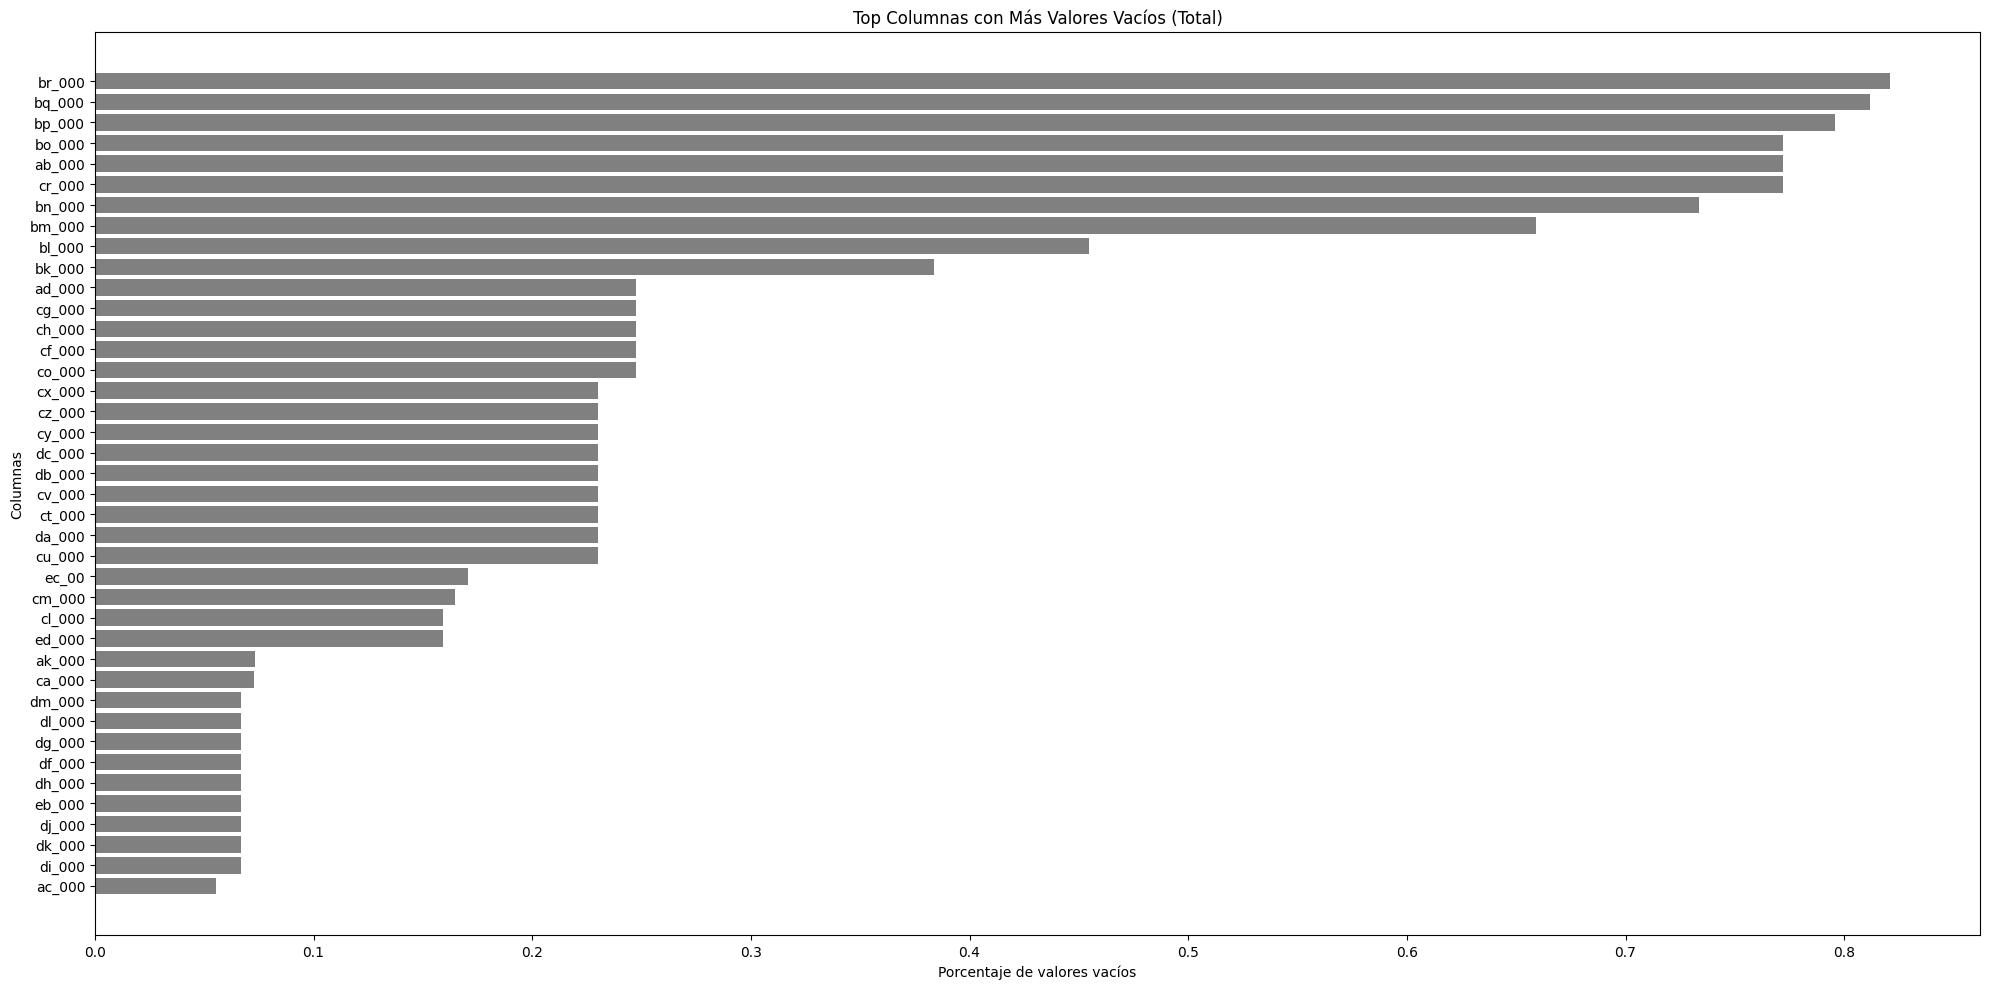

In [164]:
top = cv.sort_values(ascending=False).head(40)

plt.figure(figsize=(20, 10))
plt.barh(top.index[::-1], top.values[::-1], color='gray')
plt.xlabel('Porcentaje de valores vacíos')
plt.title('Top Columnas con Más Valores Vacíos (Total)')
plt.ylabel('Columnas')
plt.tight_layout()
plt.show()

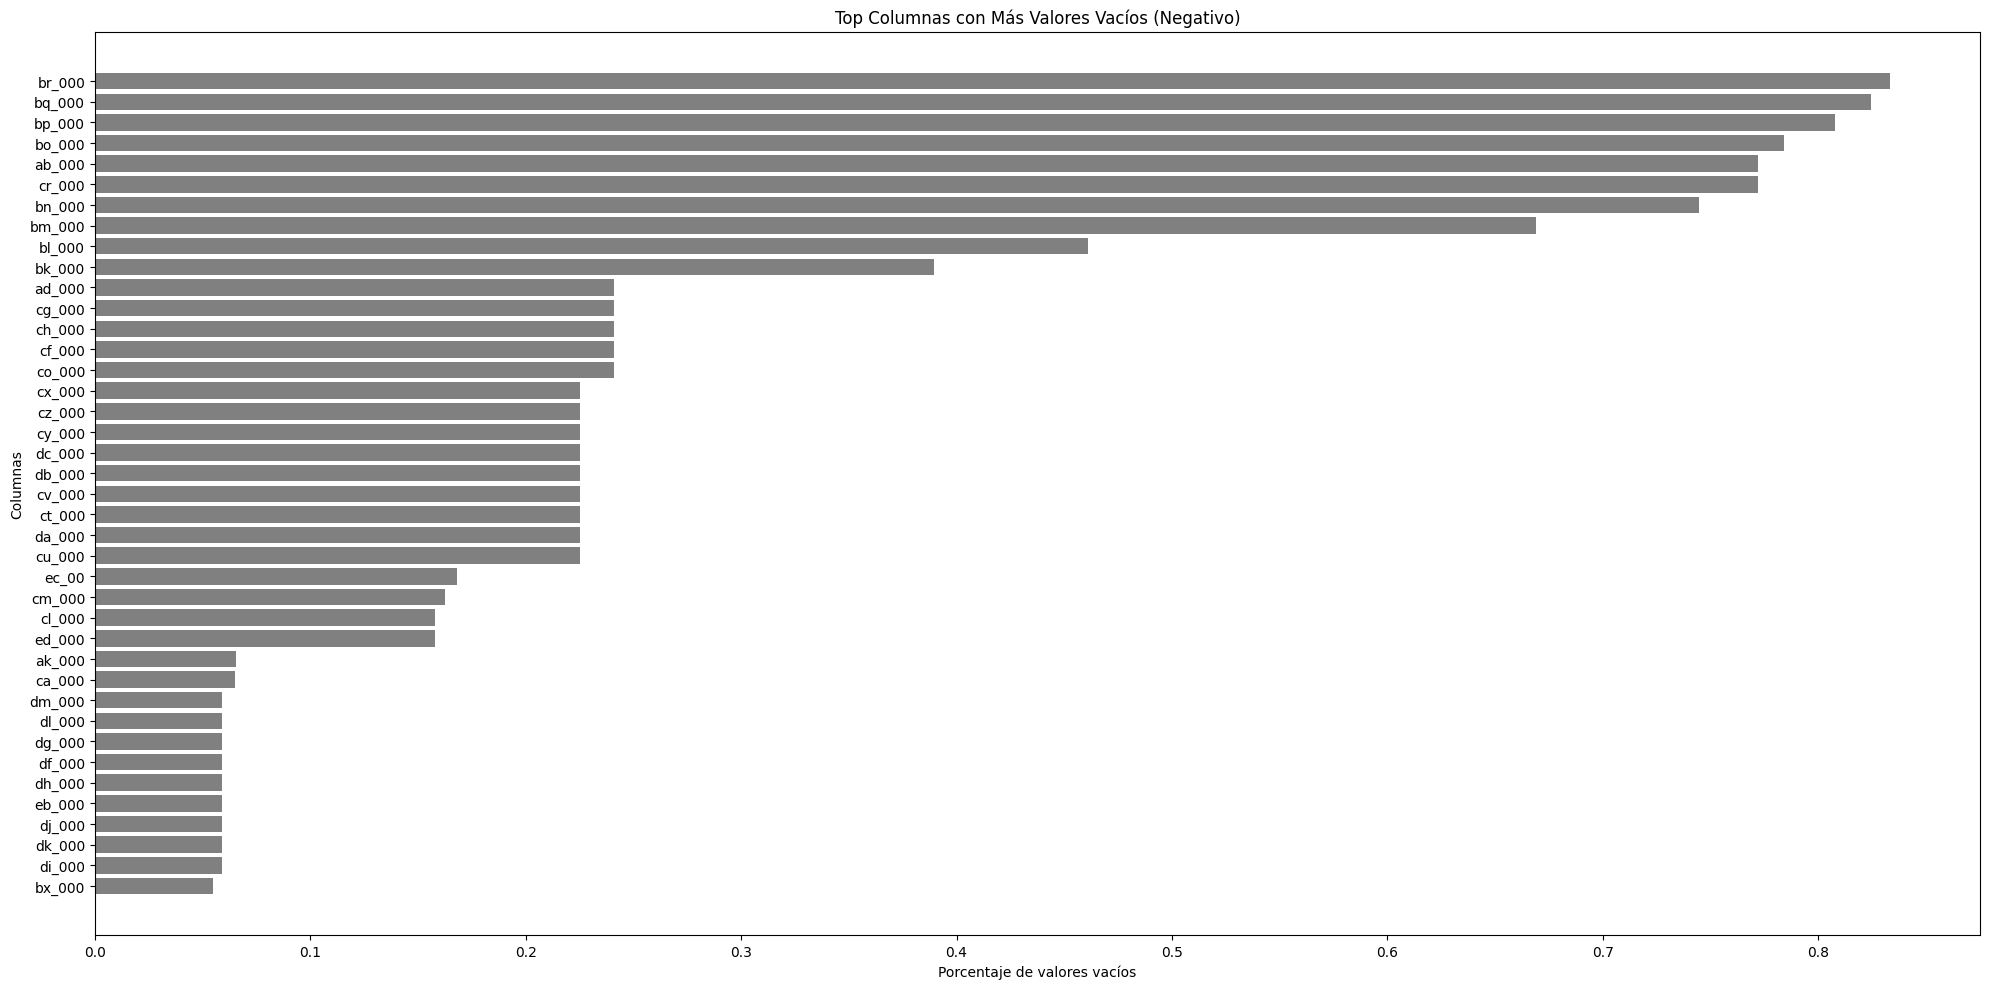

In [165]:
top_neg = cv_neg.sort_values(ascending=False).head(40)

plt.figure(figsize=(20, 10))
plt.barh(top_neg.index[::-1], top_neg.values[::-1], color='gray')
plt.xlabel('Porcentaje de valores vacíos')
plt.title('Top Columnas con Más Valores Vacíos (Negativo)')
plt.ylabel('Columnas')
plt.tight_layout()
plt.show()

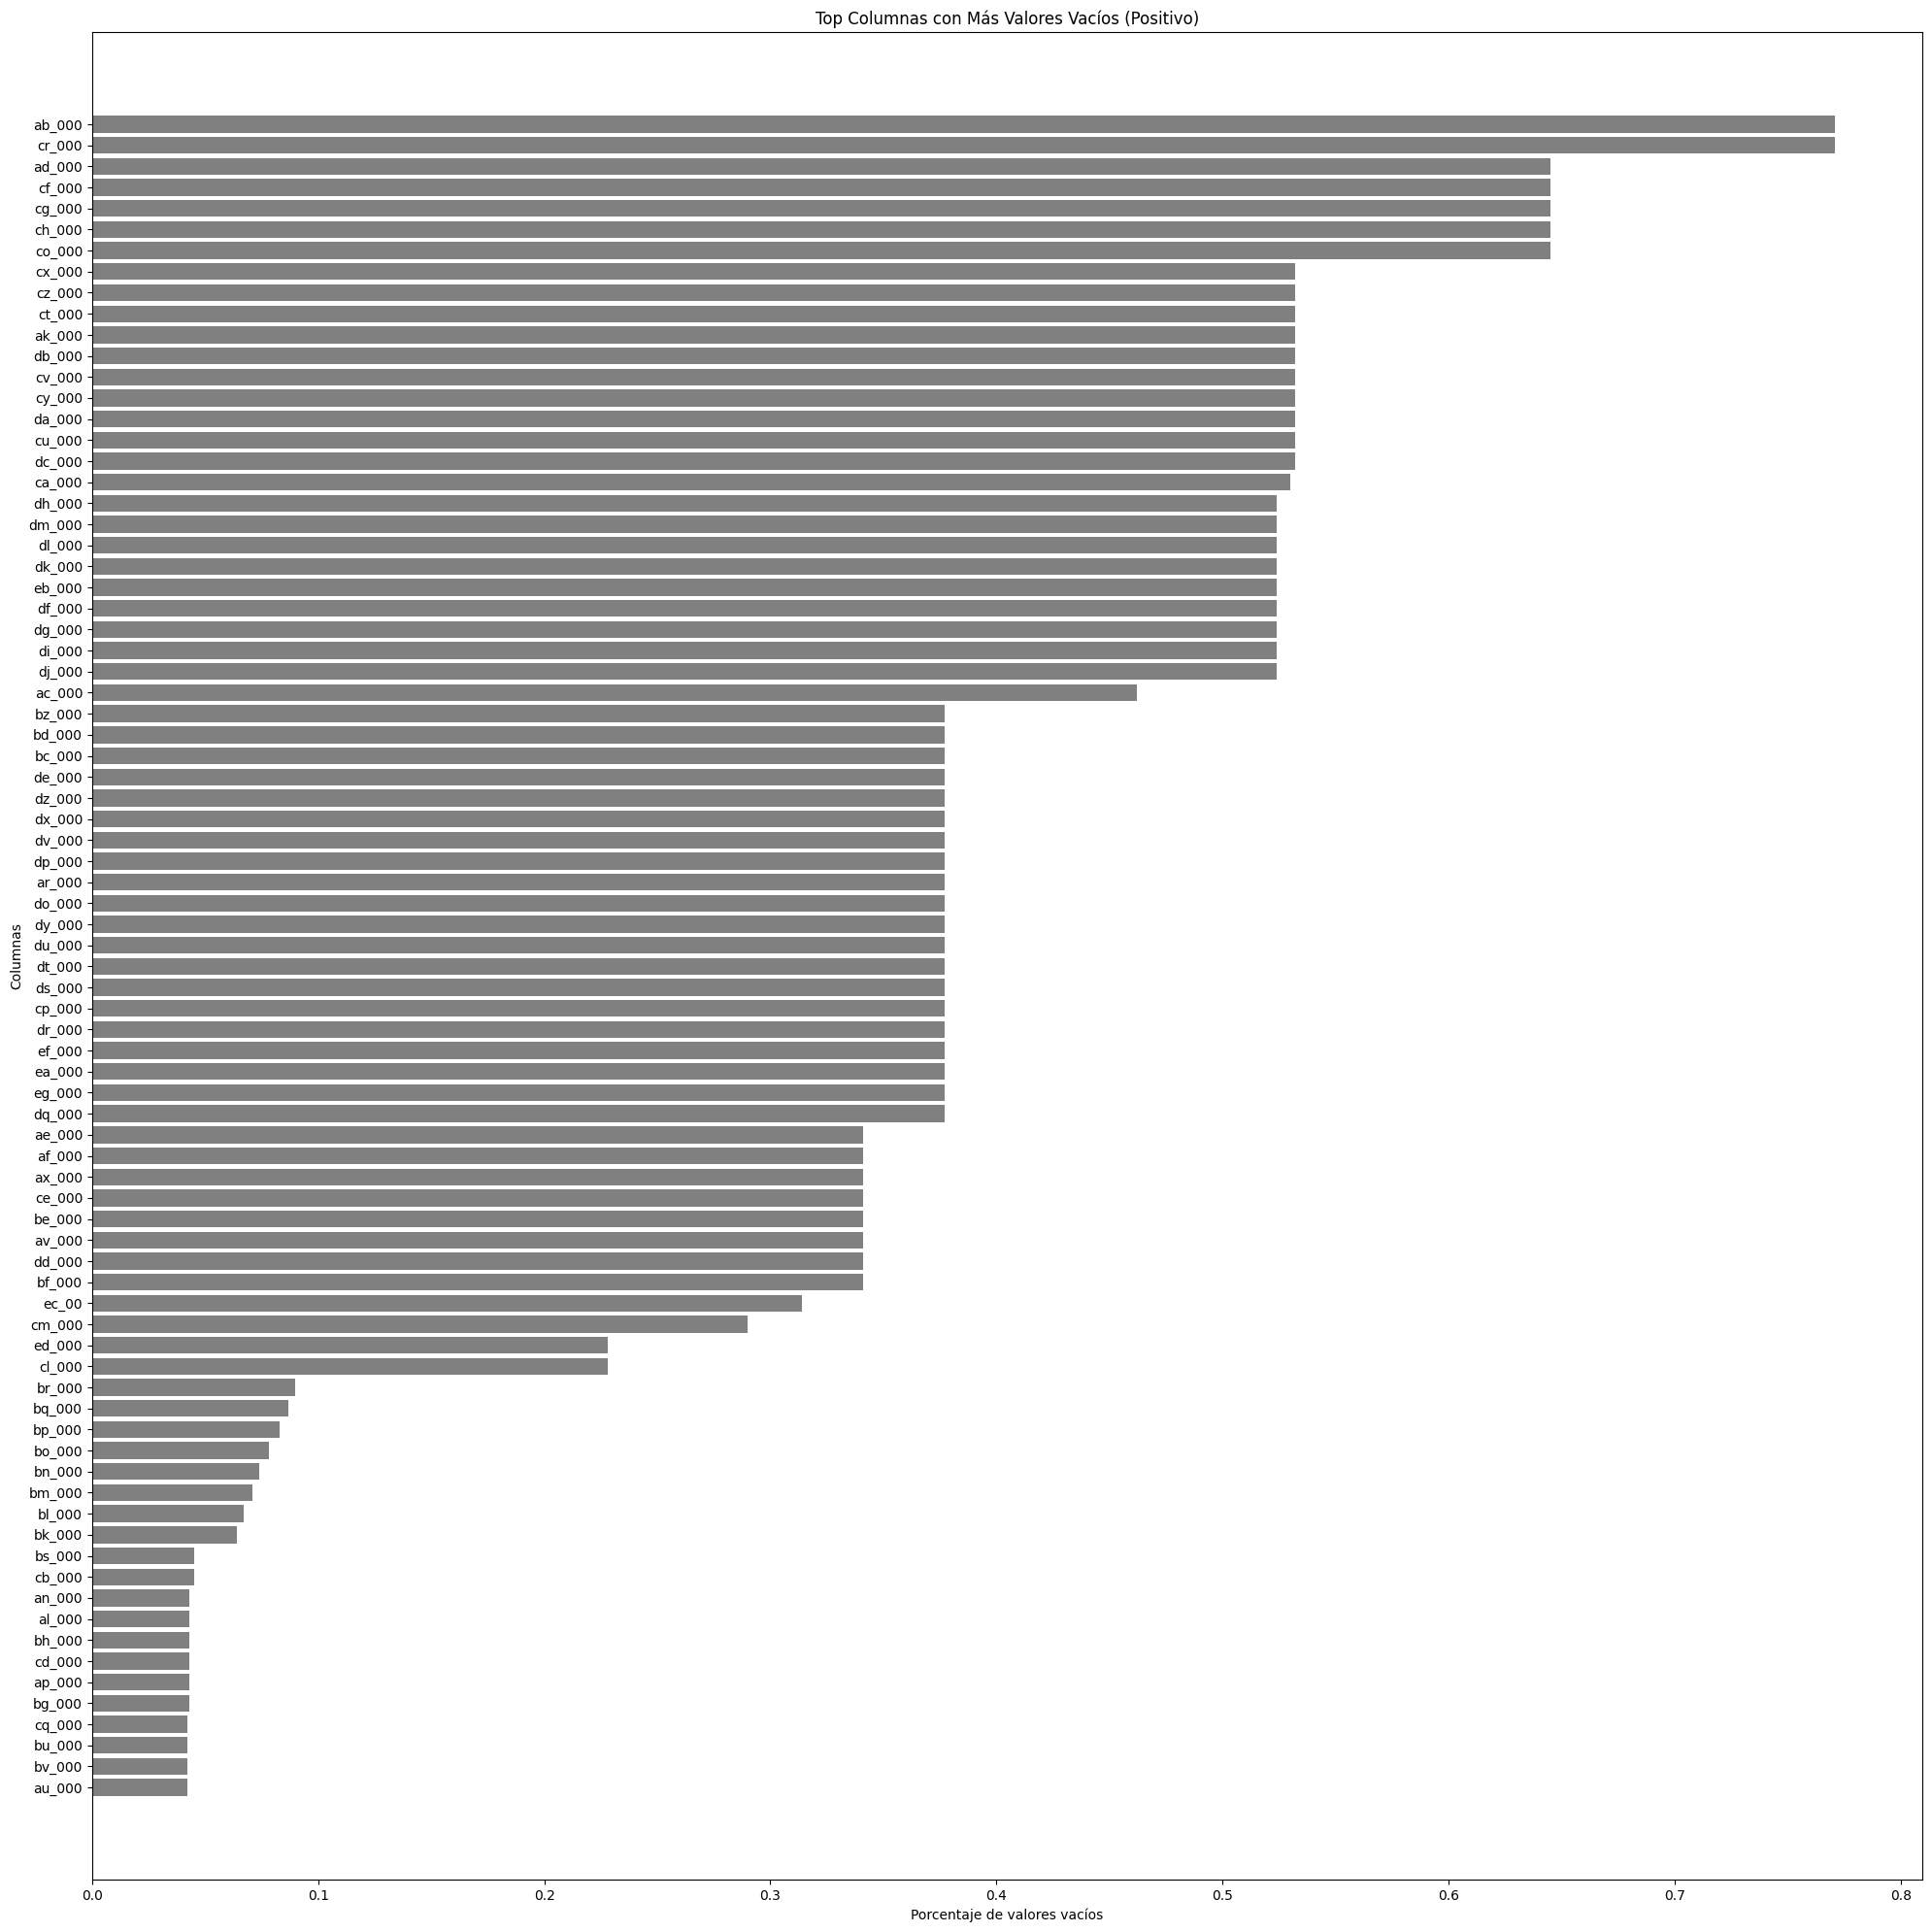

In [166]:
top_pos = cv_pos.sort_values(ascending=False).head(80)

plt.figure(figsize=(20, 20))
plt.barh(top_pos.index[::-1], top_pos.values[::-1], color='gray')
plt.xlabel('Porcentaje de valores vacíos')
plt.title('Top Columnas con Más Valores Vacíos (Positivo)')
plt.ylabel('Columnas')
plt.tight_layout()
plt.show()

#3. Limpieza del dataset train

In [167]:
# Columnas con más de 10% de "na"
umbral_total = 0.1
cols_total_umbral = cv[cv > umbral_total].index.tolist()
print("Columnas totales:")
print(cols_total_umbral)

# Columnas con más de 10% de "na"
umbral_pos = 0.1
cols_pos_umbral = cv_pos[cv_pos > umbral_pos].index.tolist()
print("Columnas positivas:")
print(cols_pos_umbral)

# Columnas con más de 10% de "na"
umbral_neg = 0.1
cols_neg_umbral = cv_neg[cv_neg > umbral_neg].index.tolist()
print("Columnas negativas:")
print(cols_neg_umbral)

Columnas totales:
['ab_000', 'ad_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'cf_000', 'cg_000', 'ch_000', 'cl_000', 'cm_000', 'co_000', 'cr_000', 'ct_000', 'cu_000', 'cv_000', 'cx_000', 'cy_000', 'cz_000', 'da_000', 'db_000', 'dc_000', 'ec_00', 'ed_000']
Columnas positivas:
['ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ak_000', 'ar_000', 'av_000', 'ax_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bz_000', 'ca_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', 'cl_000', 'cm_000', 'co_000', 'cp_000', 'cr_000', 'ct_000', 'cu_000', 'cv_000', 'cx_000', 'cy_000', 'cz_000', 'da_000', 'db_000', 'dc_000', 'dd_000', 'de_000', 'df_000', 'dg_000', 'dh_000', 'di_000', 'dj_000', 'dk_000', 'dl_000', 'dm_000', 'do_000', 'dp_000', 'dq_000', 'dr_000', 'ds_000', 'dt_000', 'du_000', 'dv_000', 'dx_000', 'dy_000', 'dz_000', 'ea_000', 'eb_000', 'ec_00', 'ed_000', 'ef_000', 'eg_000']
Columnas negativas:
['ab_000', 'ad_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', '

In [168]:
# Elemento comunes de lista de columnas a eliminar
cols_eliminar = list(set(cols_total_umbral) & set(cols_pos_umbral) & set(cols_neg_umbral))

# Eliminar columnas
df_clean = df.drop(columns=cols_eliminar)

print(df_clean.head(5))

  clase  aa_000      ac_000 ae_000 af_000 ag_000 ag_001 ag_002 ag_003 ag_004  \
0   neg   76698  2130706438      0      0      0      0      0      0  37250   
1   neg   33058           0      0      0      0      0      0      0  18254   
2   neg   41040         228      0      0      0      0      0      0   1648   
3   neg      12          70      0     10      0      0      0    318   2212   
4   neg   60874        1368      0      0      0      0      0      0  43752   

   ...   ee_002  ee_003  ee_004  ee_005  ee_006  ee_007  ee_008 ee_009 ef_000  \
0  ...  1240520  493384  721044  469792  339156  157956   73224      0      0   
1  ...   421400  178064  293306  245416  133654   81140   97576   1500      0   
2  ...   277378  159812  423992  409564  320746  158022   95128    514      0   
3  ...      240      46      58      44      10       0       0      0      4   
4  ...   622012  229790  405298  347188  286954  311560  433954   1218      0   

  eg_000  
0      0  
1      0  

In [169]:
# Cambiar negativos a 0 y positivos a 1
df_clean["clase"] = df_clean["clase"].map({"neg": 0, "pos": 1})

print(df_clean.head(5))

   clase  aa_000      ac_000 ae_000 af_000 ag_000 ag_001 ag_002 ag_003 ag_004  \
0      0   76698  2130706438      0      0      0      0      0      0  37250   
1      0   33058           0      0      0      0      0      0      0  18254   
2      0   41040         228      0      0      0      0      0      0   1648   
3      0      12          70      0     10      0      0      0    318   2212   
4      0   60874        1368      0      0      0      0      0      0  43752   

   ...   ee_002  ee_003  ee_004  ee_005  ee_006  ee_007  ee_008 ee_009 ef_000  \
0  ...  1240520  493384  721044  469792  339156  157956   73224      0      0   
1  ...   421400  178064  293306  245416  133654   81140   97576   1500      0   
2  ...   277378  159812  423992  409564  320746  158022   95128    514      0   
3  ...      240      46      58      44      10       0       0      0      4   
4  ...   622012  229790  405298  347188  286954  311560  433954   1218      0   

  eg_000  
0      0  
1   

In [170]:
# Cambiar tipo de dato
df_clean = df_clean.astype(float)

print(df_clean.head(5))

   clase   aa_000        ac_000  ae_000  af_000  ag_000  ag_001  ag_002  \
0    0.0  76698.0  2.130706e+09     0.0     0.0     0.0     0.0     0.0   
1    0.0  33058.0  0.000000e+00     0.0     0.0     0.0     0.0     0.0   
2    0.0  41040.0  2.280000e+02     0.0     0.0     0.0     0.0     0.0   
3    0.0     12.0  7.000000e+01     0.0    10.0     0.0     0.0     0.0   
4    0.0  60874.0  1.368000e+03     0.0     0.0     0.0     0.0     0.0   

   ag_003   ag_004  ...     ee_002    ee_003    ee_004    ee_005    ee_006  \
0     0.0  37250.0  ...  1240520.0  493384.0  721044.0  469792.0  339156.0   
1     0.0  18254.0  ...   421400.0  178064.0  293306.0  245416.0  133654.0   
2     0.0   1648.0  ...   277378.0  159812.0  423992.0  409564.0  320746.0   
3   318.0   2212.0  ...      240.0      46.0      58.0      44.0      10.0   
4     0.0  43752.0  ...   622012.0  229790.0  405298.0  347188.0  286954.0   

     ee_007    ee_008  ee_009  ef_000  eg_000  
0  157956.0   73224.0     0.0   

In [171]:
# Manejar los valores nulos (NaN)
from sklearn.impute import SimpleImputer

df_imputado = df_clean.copy()

imputer = SimpleImputer(strategy="median") # Se pude usar 'mean:12100', 'median:11440', 'most_frequent:11980'
df_clean = pd.DataFrame(imputer.fit_transform(df_imputado), columns=df_imputado.columns)

print(df_clean.head(5))

   clase   aa_000        ac_000  ae_000  af_000  ag_000  ag_001  ag_002  \
0    0.0  76698.0  2.130706e+09     0.0     0.0     0.0     0.0     0.0   
1    0.0  33058.0  0.000000e+00     0.0     0.0     0.0     0.0     0.0   
2    0.0  41040.0  2.280000e+02     0.0     0.0     0.0     0.0     0.0   
3    0.0     12.0  7.000000e+01     0.0    10.0     0.0     0.0     0.0   
4    0.0  60874.0  1.368000e+03     0.0     0.0     0.0     0.0     0.0   

   ag_003   ag_004  ...     ee_002    ee_003    ee_004    ee_005    ee_006  \
0     0.0  37250.0  ...  1240520.0  493384.0  721044.0  469792.0  339156.0   
1     0.0  18254.0  ...   421400.0  178064.0  293306.0  245416.0  133654.0   
2     0.0   1648.0  ...   277378.0  159812.0  423992.0  409564.0  320746.0   
3   318.0   2212.0  ...      240.0      46.0      58.0      44.0      10.0   
4     0.0  43752.0  ...   622012.0  229790.0  405298.0  347188.0  286954.0   

     ee_007    ee_008  ee_009  ef_000  eg_000  
0  157956.0   73224.0     0.0   

In [172]:
# Normalizar
from sklearn.preprocessing import MinMaxScaler, StandardScaler
df_norm = df_clean.copy()

scaler = MinMaxScaler()
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

df_clean[num_cols] = scaler.fit_transform(df_norm[num_cols])

print(df_clean.head(5))

   clase    aa_000        ac_000  ae_000    af_000  ag_000  ag_001  ag_002  \
0    0.0  0.027925  9.999998e-01     0.0  0.000000     0.0     0.0     0.0   
1    0.0  0.012036  0.000000e+00     0.0  0.000000     0.0     0.0     0.0   
2    0.0  0.014942  1.070067e-07     0.0  0.000000     0.0     0.0     0.0   
3    0.0  0.000004  3.285295e-08     0.0  0.000498     0.0     0.0     0.0   
4    0.0  0.022164  6.420405e-07     0.0  0.000000     0.0     0.0     0.0   

     ag_003    ag_004  ...    ee_002    ee_003        ee_004        ee_005  \
0  0.000000  0.000163  ...  0.015918  0.013067  7.421784e-03  8.179508e-03   
1  0.000000  0.000080  ...  0.005407  0.004716  3.019031e-03  4.272917e-03   
2  0.000000  0.000007  ...  0.003559  0.004232  4.364196e-03  7.130884e-03   
3  0.000005  0.000010  ...  0.000003  0.000001  5.970003e-07  7.660803e-07   
4  0.000000  0.000191  ...  0.007981  0.006086  4.171776e-03  6.044861e-03   

         ee_006    ee_007    ee_008    ee_009    ef_000    eg_

In [173]:
# Separacion de negativos y positivos
df_clean_neg = df_clean[df_clean['clase'] == 0]
df_clean_pos = df_clean[df_clean['clase'] == 1]

print(f"N° negativos orginales: {len(df_clean_neg)}, N° positivos originales: {len(df_clean_pos)}")

N° negativos orginales: 59000, N° positivos originales: 1000


In [174]:
# Se eliminan algunas filas de los negativos (undersampling)
# Muestra mejor precio con ratio menor

from sklearn.utils import resample

ratio = 1

df_neg_down = resample(df_clean_neg,
                       replace=False,     # sin reemplazo
                       n_samples= ratio*len(df_pos),
                       random_state=42)

# Nuevo dataset balanceado
df_clean = pd.concat([df_clean_pos, df_neg_down])

print(f"N° negativos balanceados: {len(df_clean[df_clean['clase'] == 0])}, N° positivos balanceados: {len(df_clean[df_clean['clase'] == 1])}")

N° negativos balanceados: 1000, N° positivos balanceados: 1000


In [175]:
# Se agregan algunas filas de los positivos (oversampling)
# 133.27 segundos para entrenamiento

# from sklearn.utils import resample

# df_pos_up  = resample(df_clean_pos,
#                        replace=True,     # con reemplazo
#                        n_samples=len(df_pos),
#                        random_state=42)

# # Nuevo dataset balanceado
# df_clean = pd.concat([df_pos_up, df_clean_neg])

# print(f"N° negativos balanceados: {len(df_clean[df_clean['clase'] == 0])}, N° positivos balanceados: {len(df_clean[df_clean['clase'] == 1])}")

#4. Procesar dataset test

In [176]:
# Tamaño del dataset
print(test.shape)

(16000, 171)


In [177]:

test.rename(columns={'class': 'clase'}, inplace=True) # Cambiar titulo de columna

test_clean = test.replace("na", np.nan) # Cambiar 'na' a NaN

test_clean = test_clean.drop(columns=cols_eliminar) # Elmimina las mismas columnas que en train

test_clean["clase"] = test_clean["clase"].map({"neg": 0, "pos": 1}) # Cambiar 'neg' a 0 y 'pos' a 1

test_clean = test_clean.astype(float) # Cambia el tipo de dato

test_clean = pd.DataFrame(imputer.transform(test_clean), columns=test_clean.columns) # Tratar los vacios con la configuracion en train

test_clean[num_cols] = scaler.transform(test_clean[num_cols]) # Normalizar con la configuracion en train

print(test_clean.head(5))

   clase    aa_000        ac_000  ae_000  af_000  ag_000  ag_001  ag_002  \
0    0.0  0.000022  9.386557e-09     0.0     0.0     0.0     0.0     0.0   
1    0.0  0.000030  3.191429e-08     0.0     0.0     0.0     0.0     0.0   
2    0.0  0.024031  9.949750e-08     0.0     0.0     0.0     0.0     0.0   
3    0.0  0.021778  4.740211e-07     0.0     0.0     0.0     0.0     0.0   
4    0.0  0.000660  7.321514e-08     0.0     0.0     0.0     0.0     0.0   

     ag_003        ag_004  ...    ee_002    ee_003    ee_004    ee_005  \
0  0.000042  2.069654e-05  ...  0.000014  0.000004  0.000004  0.000011   
1  0.000000  3.268794e-06  ...  0.000014  0.000007  0.000017  0.000002   
2  0.003146  5.936864e-03  ...  0.006353  0.010074  0.004530  0.004693   
3  0.000000  5.415448e-04  ...  0.006939  0.006443  0.004975  0.008450   
4  0.000000  3.146433e-07  ...  0.000098  0.000110  0.000190  0.000867   

     ee_006        ee_007    ee_008    ee_009  ef_000  eg_000  
0  0.000002  7.359084e-07  0.00000

#5. Entrenamiento del modelo

In [178]:
x_train = df_clean.drop(columns=['clase'])
y_train = df_clean['clase']

x_test  = test_clean.drop(columns=['clase'])
y_test  = test_clean['clase']

In [179]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import time

# Inicialización y entrenamiento del modelo
model = RandomForestClassifier(random_state=100)

start = time.time()

# Entrenar
model.fit(x_train, y_train)

end = time.time()

print(f"Tiempo de entrenamiento: {end - start:.2f} segundos")

# Predecir
y_pred = model.predict(x_test)

Tiempo de entrenamiento: 1.85 segundos


In [180]:
# Métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9499
Precision: 0.3167
Recall: 0.9813
F1-score: 0.4789


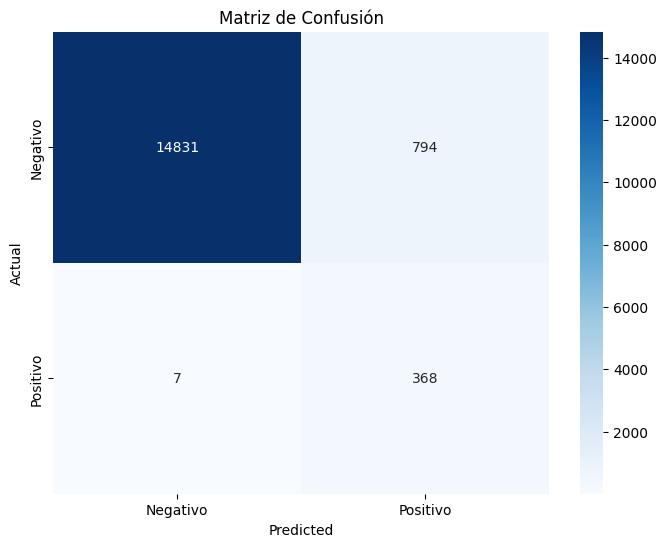

In [181]:
# 3. Evaluación
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión')
plt.show()

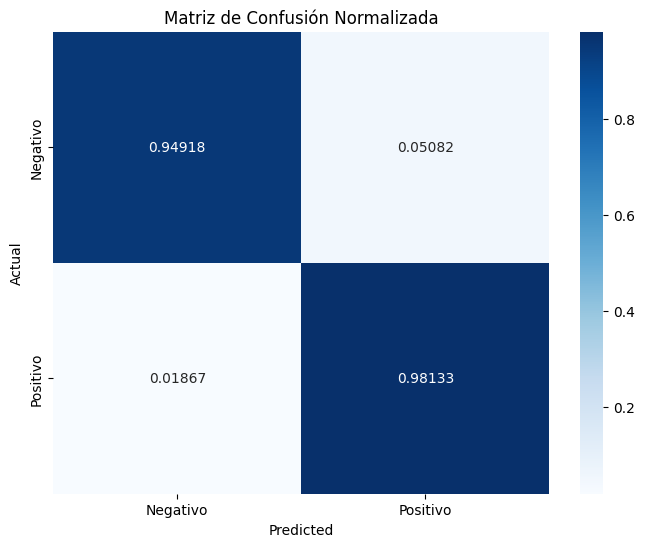

In [182]:
# Normalizar por fila (dividir cada valor por el total real de la clase)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.5f', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión Normalizada')
plt.show()

In [183]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97     15625
         1.0       0.32      0.98      0.48       375

    accuracy                           0.95     16000
   macro avg       0.66      0.97      0.73     16000
weighted avg       0.98      0.95      0.96     16000



In [184]:
# Definir los costos
Cost_1 = 10  # Revisión innecesaria
Cost_2 = 500  # No detectar falla

# Extraer los valores de la matriz de confusión
TP = cm[1, 1]  # True Positives
TN = cm[0, 0]  # True Negatives
FP = cm[0, 1]  # False Positives
FN = cm[1, 0]  # False Negatives

# Calcular el coste total
Total_cost = Cost_1 * FP + Cost_2 * FN
print(f"Numero de revisiones innecesarias: {FP}")
print(f"Numero de fallas no detectadas: {FN}")
print(f"Costo total: {Total_cost:.2f}")

Numero de revisiones innecesarias: 794
Numero de fallas no detectadas: 7
Costo total: 11440.00


#6. Entrenamiento de Modelo LSTM

In [185]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import seaborn as sns

In [186]:
# Separar características y etiquetas
X = df_clean.drop(columns=["clase"]).values
y = df_clean["clase"].values

# División en train y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Convertir a formato [samples, timesteps, features]
X_train = np.expand_dims(X_train, axis=1)
X_val = np.expand_dims(X_val, axis=1)

In [187]:
# Crear modelo LSTM
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compilar modelo
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [188]:
# Entrenar modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    verbose=1
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6754 - loss: 0.6669 - val_accuracy: 0.8750 - val_loss: 0.5611
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9197 - loss: 0.5024 - val_accuracy: 0.9075 - val_loss: 0.3983
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9284 - loss: 0.3253 - val_accuracy: 0.9150 - val_loss: 0.3295
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9393 - loss: 0.2334 - val_accuracy: 0.9125 - val_loss: 0.3083
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9485 - loss: 0.1945 - val_accuracy: 0.9150 - val_loss: 0.2913
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9358 - loss: 0.2090 - val_accuracy: 0.9150 - val_loss: 0.2728
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9540 - loss: 0.1686 - val_accuracy: 0.9200 - val_loss: 0.2635
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9454 - loss: 0.1811 - val_accuracy: 0.9250 - val_los

In [189]:
# Preparar test
X_test = test_clean.drop(columns=["clase"]).values
y_test = test_clean["clase"].values
X_test = np.expand_dims(X_test, axis=1)

# Predicciones
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


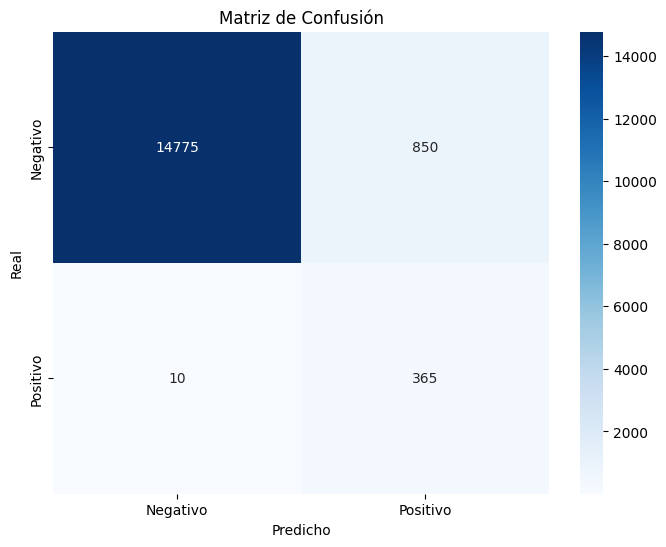

In [190]:
# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

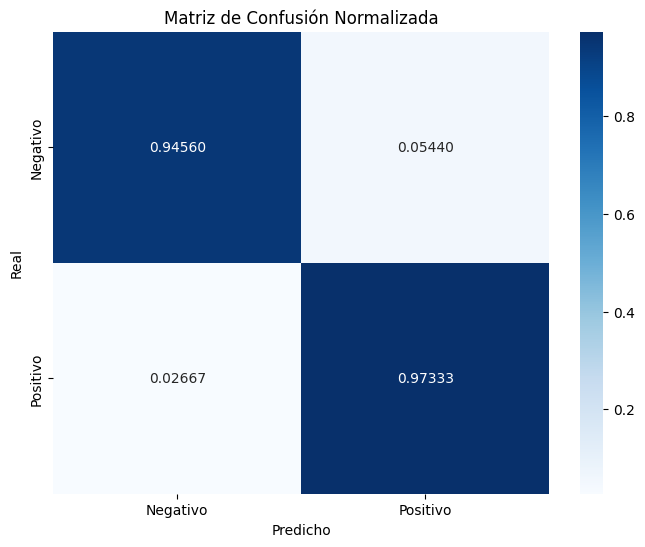

In [191]:
# Matriz de Confusión Normalizada
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.5f', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Normalizada')
plt.show()

In [192]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97     15625
         1.0       0.30      0.97      0.46       375

    accuracy                           0.95     16000
   macro avg       0.65      0.96      0.72     16000
weighted avg       0.98      0.95      0.96     16000



In [193]:
# Definir los costos
Cost_1 = 10  # Revisión innecesaria
Cost_2 = 500  # No detectar falla

# Extraer los valores de la matriz de confusión
TP = cm[1, 1]  # True Positives
TN = cm[0, 0]  # True Negatives
FP = cm[0, 1]  # False Positives
FN = cm[1, 0]  # False Negatives

# Calcular el coste total
Total_cost = Cost_1 * FP + Cost_2 * FN
print(f"Numero de revisiones innecesarias: {FP}")
print(f"Numero de fallas no detectadas: {FN}")
print(f"Costo total: {Total_cost:.2f}")


Numero de revisiones innecesarias: 850
Numero de fallas no detectadas: 10
Costo total: 13500.00


#7. Entrenamiento de Modelo de Red Neuronal Profunda mediante Aprendizaje Supervisado

In [194]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [195]:
# Parametros
batch_size = 256
epochs = 200
learning_rate = 0.001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [196]:
# Separar variables predictoras y etiquetas
X_train = df_clean.drop(columns=["clase"]).values
y_train = df_clean["clase"].values

X_test = test_clean.drop(columns=["clase"]).values
y_test = test_clean["clase"].values

In [197]:
# Convertir a tensores
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [198]:
# Crear DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [199]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super(MLPClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

In [200]:
# Crear modelo
input_dim = X.shape[1]
model = MLPClassifier(input_dim).to(device)
print(model)

MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=150, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


In [201]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

losses_train = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    losses_train.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_loss:.4f}")

Epoch [1/200] - Train Loss: 0.6775
Epoch [2/200] - Train Loss: 0.5757
Epoch [3/200] - Train Loss: 0.3758
Epoch [4/200] - Train Loss: 0.2438
Epoch [5/200] - Train Loss: 0.2225
Epoch [6/200] - Train Loss: 0.2064
Epoch [7/200] - Train Loss: 0.1797
Epoch [8/200] - Train Loss: 0.1769
Epoch [9/200] - Train Loss: 0.1708
Epoch [10/200] - Train Loss: 0.1599
Epoch [11/200] - Train Loss: 0.1616
Epoch [12/200] - Train Loss: 0.1586
Epoch [13/200] - Train Loss: 0.1566
Epoch [14/200] - Train Loss: 0.1468
Epoch [15/200] - Train Loss: 0.1492
Epoch [16/200] - Train Loss: 0.1469
Epoch [17/200] - Train Loss: 0.1432
Epoch [18/200] - Train Loss: 0.1419
Epoch [19/200] - Train Loss: 0.1362
Epoch [20/200] - Train Loss: 0.1345
Epoch [21/200] - Train Loss: 0.1280
Epoch [22/200] - Train Loss: 0.1280
Epoch [23/200] - Train Loss: 0.1249
Epoch [24/200] - Train Loss: 0.1201
Epoch [25/200] - Train Loss: 0.1157
Epoch [26/200] - Train Loss: 0.1148
Epoch [27/200] - Train Loss: 0.1135
Epoch [28/200] - Train Loss: 0.1082
E

In [202]:
model.eval()
y_pred_list = []
y_true_list = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        outputs = model(batch_x)
        preds = (outputs > 0.5).int().cpu().numpy()
        y_pred_list.extend(preds)
        y_true_list.extend(batch_y.cpu().numpy())

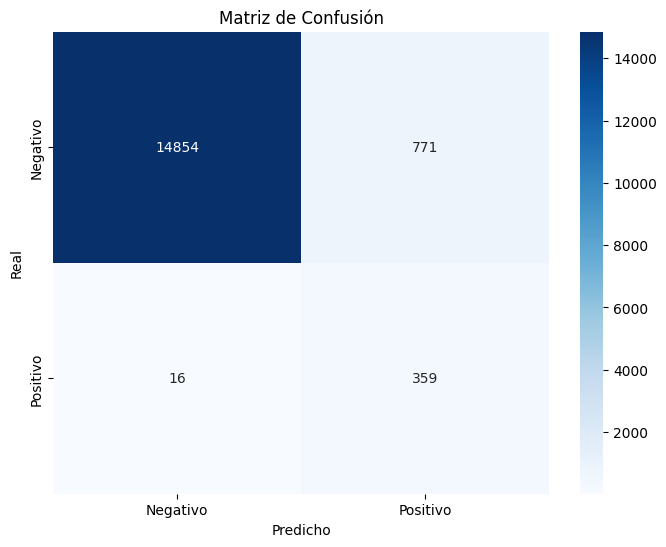

In [203]:
cm = confusion_matrix(y_true_list, y_pred_list)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

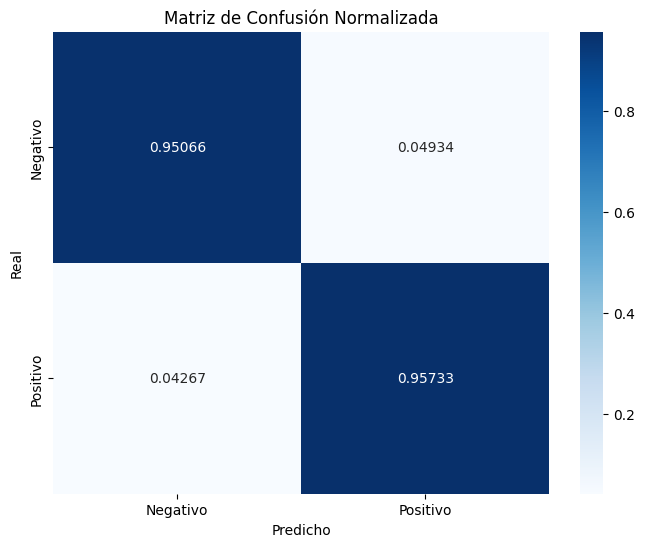

In [204]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.5f', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Normalizada')
plt.show()

In [205]:
print("\nReporte de clasificación:")
print(classification_report(y_true_list, y_pred_list))


Reporte de clasificación:
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97     15625
         1.0       0.32      0.96      0.48       375

    accuracy                           0.95     16000
   macro avg       0.66      0.95      0.73     16000
weighted avg       0.98      0.95      0.96     16000



In [206]:
Cost_1 = 10    # Revisión innecesaria
Cost_2 = 500   # No detectar falla

TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

Total_cost = Cost_1 * FP + Cost_2 * FN

print(f"Número de revisiones innecesarias (FP): {FP}")
print(f"Número de fallas no detectadas (FN): {FN}")
print(f"Costo total: {Total_cost:.2f}")

Número de revisiones innecesarias (FP): 771
Número de fallas no detectadas (FN): 16
Costo total: 15710.00


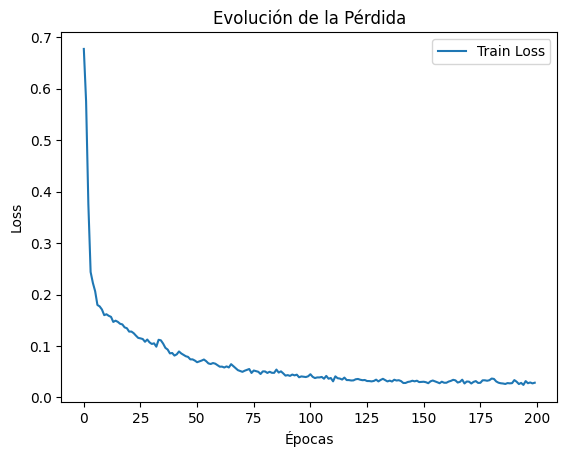

In [207]:
# Curva de pérdida
plt.figure()
plt.plot(losses_train, label='Train Loss')
plt.legend()
plt.title('Evolución de la Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.show()